<a href="https://colab.research.google.com/github/Taewookkwak-knou/Data-Analysis-with-Open-Source/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EA%B3%BC%EC%A0%9C%EB%AC%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# [STEP 1] 라이브러리 import + 한글 폰트 설정
!apt-get -qq install -y fonts-nanum > /dev/null

import requests, time, json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

print('pandas :', pd.__version__)
print('requests:', requests.__version__)
print('한글 폰트 설정 완료')

pandas : 2.2.3
requests: 2.32.4
한글 폰트 설정 완료


In [3]:
# [STEP 2] 인증키 설정 + API 단일 호출 테스트 (문 1-2 동작 확인 : totalCount == 66)
from urllib.parse import unquote

SERVICE_KEY = "78c8d2fee4e777332bb4d649e47fa70de39e755d1c7192491a68b01b6796aaa6"   # 공공데이터포털 마이페이지의 일반 인증키
STUDENT_ID4 = "2187"                                  # 본인 학번 뒤 4자리 (문 3-1 그래프 제목용)

KEY = unquote(SERVICE_KEY)   # Encoding / Decoding 키 어느 쪽을 넣어도 동작하도록 처리
URL = "https://apis.data.go.kr/B552845/perDay/price"

BASE_COND = {
    "cond[se_cd::EQ]":    "02",       # 구분코드 : 중도매(도매)
    "cond[ctgry_cd::EQ]": "200",      # 부류코드 : 채소류
    "cond[item_cd::EQ]":  "211",      # 품목코드 : 배추
    "cond[grd_cd::EQ]":   "04",       # 등급코드 : 상품
    "cond[sgg_cd::EQ]":   "1101",     # 시군구코드 : 서울
    "cond[mrkt_cd::EQ]":  "0110211",  # 시장코드 : 가락도매
}

params = {
    "serviceKey": KEY,
    "pageNo": 1,
    "numOfRows": 200,
    "returnType": "JSON",
    "cond[exmn_ymd::GTE]": "20150101",
    "cond[exmn_ymd::LTE]": "20151231",
    "cond[vrty_cd::EQ]": "01",        # 품종코드 : 봄배추
    **BASE_COND,
}

res = requests.get(URL, params=params, timeout=30)
print("HTTP status :", res.status_code)

body = res.json()["response"]["body"]
print("totalCount  :", body["totalCount"], "  <-- 66 이면 정상")

items = body.get("items") or []
if isinstance(items, dict):
    items = items.get("item", [])
print("수신 건수   :", len(items))
print()
print("[첫 번째 레코드]")
print(json.dumps(items[0], ensure_ascii=False, indent=2))

HTTP status : 200
totalCount  : 66   <-- 66 이면 정상
수신 건수   : 66

[첫 번째 레코드]
{
  "ctgry_cd": "200",
  "ctgry_nm": "채소류",
  "exmn_dd_cnvs_prc": "9000",
  "exmn_dd_prc": "9000",
  "exmn_ymd": "20150512",
  "grd_cd": "04",
  "grd_nm": "상품",
  "item_cd": "211",
  "item_nm": "배추",
  "mrkt_cd": "0110211",
  "mrkt_nm": "가락도매",
  "orgnl_reg_dt": "2015-05-12T13:53:35Z",
  "se_cd": "02",
  "se_nm": "중도매",
  "sgg_cd": "1101",
  "sgg_nm": "서울",
  "unit": "kg(그물망 3포기)",
  "unit_sz": "10",
  "vrty_cd": "01",
  "vrty_nm": "봄"
}


In [4]:
# [STEP 3] 2015 ~ 2024년 × 4개 품종 전체 수집 (문 1-2 본 수집)
YEARS = range(2015, 2025)
VRTY = {"01": "봄배추", "02": "여름배추(고랭지)", "03": "가을배추", "06": "월동배추"}

def fetch_page(year, vrty_cd, page_no=1, num_rows=200):
    """연도·품종·페이지 단위로 API를 호출해 (전체건수, 레코드 리스트)를 반환"""
    p = {
        "serviceKey": KEY,
        "pageNo": page_no,
        "numOfRows": num_rows,
        "returnType": "JSON",
        "cond[exmn_ymd::GTE]": f"{year}0101",
        "cond[exmn_ymd::LTE]": f"{year}1231",
        "cond[vrty_cd::EQ]": vrty_cd,
        **BASE_COND,
    }
    r = requests.get(URL, params=p, timeout=30)
    r.raise_for_status()
    b = r.json()["response"]["body"]
    its = b.get("items") or []
    if isinstance(its, dict):
        its = its.get("item", [])
    return int(b.get("totalCount", 0)), its

raw_rows = []
for year in YEARS:
    for vcode, vname in VRTY.items():
        page, got = 1, 0
        while True:                                    # numOfRows(200)를 넘으면 페이징 반복
            total, items = fetch_page(year, vcode, page)
            for it in items:
                rec = dict(it)
                rec["vrty_label"] = vname              # 그래프 범례용 품종명
                raw_rows.append(rec)
            got += len(items)
            if got >= total or not items:
                break
            page += 1
            time.sleep(0.1)
        print(f"{year}  {vname:<14} : {got:4d}건  (totalCount={total})")
        time.sleep(0.1)

print()
print("총 수집 건수 :", len(raw_rows))

2015  봄배추            :   66건  (totalCount=66)
2015  여름배추(고랭지)      :   64건  (totalCount=64)
2015  가을배추           :   45건  (totalCount=45)
2015  월동배추           :   97건  (totalCount=97)
2016  봄배추            :   70건  (totalCount=70)
2016  여름배추(고랭지)      :   72건  (totalCount=72)
2016  가을배추           :   48건  (totalCount=48)
2016  월동배추           :   87건  (totalCount=87)
2017  봄배추            :   67건  (totalCount=67)
2017  여름배추(고랭지)      :   57건  (totalCount=57)
2017  가을배추           :   48건  (totalCount=48)
2017  월동배추           :   86건  (totalCount=86)
2018  봄배추            :   48건  (totalCount=48)
2018  여름배추(고랭지)      :   74건  (totalCount=74)
2018  가을배추           :   48건  (totalCount=48)
2018  월동배추           :   94건  (totalCount=94)
2019  봄배추            :   43건  (totalCount=43)
2019  여름배추(고랭지)      :   65건  (totalCount=65)
2019  가을배추           :   53건  (totalCount=53)
2019  월동배추           :   97건  (totalCount=97)
2020  봄배추            :   51건  (totalCount=51)
2020  여름배추(고랭지)      :   66건  (tot

In [5]:
# [STEP 4] 수집한 JSON 데이터를 pandas DataFrame으로 변환 + 기본 정보 출력 (문 2-1)
df = pd.DataFrame(raw_rows)

# API 응답은 모든 값이 문자열이므로 가격·규격을 숫자형으로 변환
df["exmn_dd_prc"] = pd.to_numeric(df["exmn_dd_prc"], errors="coerce")
df["unit_sz"]     = pd.to_numeric(df["unit_sz"], errors="coerce")

print("데이터 크기(shape) :", df.shape)
print()
print("[컬럼 정보]")
df.info()
print()
print("[결측치 개수]")
print(df.isnull().sum())
print()
print("[거래 단위(unit) 확인]")
print(df["unit"].value_counts())
print()
print("[기술통계 - 일일가격]")
display(df[["exmn_dd_prc"]].describe())
print("[상위 5개 행]")
display(df.head())

df.to_csv("cabbage_garak_2015_2024.csv", index=False, encoding="utf-8-sig")
print("CSV 저장 완료 : cabbage_garak_2015_2024.csv")

데이터 크기(shape) : (2644, 21)

[컬럼 정보]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ctgry_cd          2644 non-null   object
 1   ctgry_nm          2644 non-null   object
 2   exmn_dd_cnvs_prc  2644 non-null   object
 3   exmn_dd_prc       2644 non-null   int64 
 4   exmn_ymd          2644 non-null   object
 5   grd_cd            2644 non-null   object
 6   grd_nm            2644 non-null   object
 7   item_cd           2644 non-null   object
 8   item_nm           2644 non-null   object
 9   mrkt_cd           2644 non-null   object
 10  mrkt_nm           2644 non-null   object
 11  orgnl_reg_dt      2644 non-null   object
 12  se_cd             2644 non-null   object
 13  se_nm             2644 non-null   object
 14  sgg_cd            2644 non-null   object
 15  sgg_nm            2644 non-null   object
 16  unit              2644 n

,exmn_dd_prc
count,2644.000000
mean,10288.018154
std,5887.043779
min,3000.000000
25%,6500.000000
50%,9000.000000
75%,12000.000000
max,49800.000000


[상위 5개 행]


,ctgry_cd,ctgry_nm,exmn_dd_cnvs_prc,exmn_dd_prc,exmn_ymd,grd_cd,grd_nm,item_cd,item_nm,mrkt_cd,...,orgnl_reg_dt,se_cd,se_nm,sgg_cd,sgg_nm,unit,unit_sz,vrty_cd,vrty_nm,vrty_label
0,200,채소류,9000,9000,20150512,04,상품,211,배추,0110211,...,2015-05-12T13:53:35Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄,봄배추
1,200,채소류,8000,8000,20150513,04,상품,211,배추,0110211,...,2015-05-13T13:47:27Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄,봄배추
2,200,채소류,8000,8000,20150514,04,상품,211,배추,0110211,...,2015-05-18T14:51:22Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄,봄배추
3,200,채소류,8000,8000,20150515,04,상품,211,배추,0110211,...,2015-05-18T14:57:50Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄,봄배추
4,200,채소류,10000,10000,20150518,04,상품,211,배추,0110211,...,2015-05-21T11:25:53Z,02,중도매,1101,서울,kg(그물망 3포기),10,01,봄,봄배추


CSV 저장 완료 : cabbage_garak_2015_2024.csv


In [6]:
# [STEP 5] 조사일자(exmn_ymd)로 연도(year)·계절(season) 컬럼 추가 (문 2-2)
df["exmn_ymd"] = df["exmn_ymd"].astype(str)
df["date"]  = pd.to_datetime(df["exmn_ymd"], format="%Y%m%d")
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.month

def to_season(m):
    """월 -> 계절 (봄 3~5 / 여름 6~8 / 가을 9~11 / 겨울 12~2)"""
    if m in (3, 4, 5):
        return "봄"
    elif m in (6, 7, 8):
        return "여름"
    elif m in (9, 10, 11):
        return "가을"
    else:
        return "겨울"

df["season"] = df["month"].apply(to_season)
df["season"] = pd.Categorical(df["season"], categories=["봄", "여름", "가을", "겨울"], ordered=True)

print("[변환 결과 확인]")
display(df[["exmn_ymd", "year", "month", "season", "vrty_label", "exmn_dd_prc"]].head(10))
print()
print("[연도별 데이터 건수]")
print(df["year"].value_counts().sort_index())
print()
print("[계절별 데이터 건수]")
print(df["season"].value_counts().sort_index())

[변환 결과 확인]


,exmn_ymd,year,month,season,vrty_label,exmn_dd_prc
0,20150512,2015,5,봄,봄배추,9000
1,20150513,2015,5,봄,봄배추,8000
2,20150514,2015,5,봄,봄배추,8000
3,20150515,2015,5,봄,봄배추,8000
4,20150518,2015,5,봄,봄배추,10000
5,20150519,2015,5,봄,봄배추,11000
6,20150520,2015,5,봄,봄배추,11000
7,20150521,2015,5,봄,봄배추,11000
8,20150522,2015,5,봄,봄배추,10000
9,20150526,2015,5,봄,봄배추,10000



[연도별 데이터 건수]
year
2015    272
2016    277
2017    258
2018    264
2019    258
2020    282
2021    256
2022    256
2023    257
2024    264
Name: count, dtype: int64

[계절별 데이터 건수]
season
봄     690
여름    662
가을    654
겨울    638
Name: count, dtype: int64


[연도별 평균 가격]
year
2015     5930.1
2016    10707.6
2017     9271.3
2018     8751.9
2019     7631.8
2020    11439.0
2021     8514.1
2022    13095.3
2023    11712.1
2024    15845.5
Name: exmn_dd_prc, dtype: float64


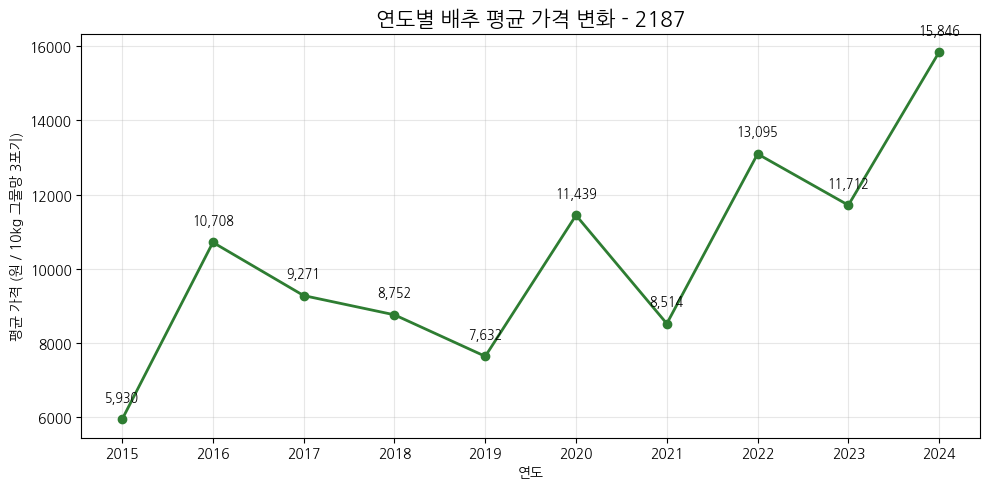

In [7]:
# [STEP 6] 연도별 배추 평균 가격 변화 - 선 그래프 (문 3-1)
yearly = df.groupby("year")["exmn_dd_prc"].mean()
print("[연도별 평균 가격]")
print(yearly.round(1))

plt.figure(figsize=(10, 5))
plt.plot(yearly.index, yearly.values, marker="o", linewidth=2, color="#2E7D32")

for x, y in zip(yearly.index, yearly.values):
    plt.text(x, y + 500, f"{y:,.0f}", ha="center", fontsize=9)

plt.title(f"연도별 배추 평균 가격 변화 - {STUDENT_ID4}", fontsize=15)
plt.xlabel("연도")
plt.ylabel("평균 가격 (원 / 10kg 그물망 3포기)")
plt.xticks(yearly.index)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"연도별_배추_평균가격_{STUDENT_ID4}.png", dpi=150)
plt.show()

[계절별 평균 가격]
season
봄      9497.7
여름    11121.3
가을    12928.1
겨울     7571.8
Name: exmn_dd_prc, dtype: float64


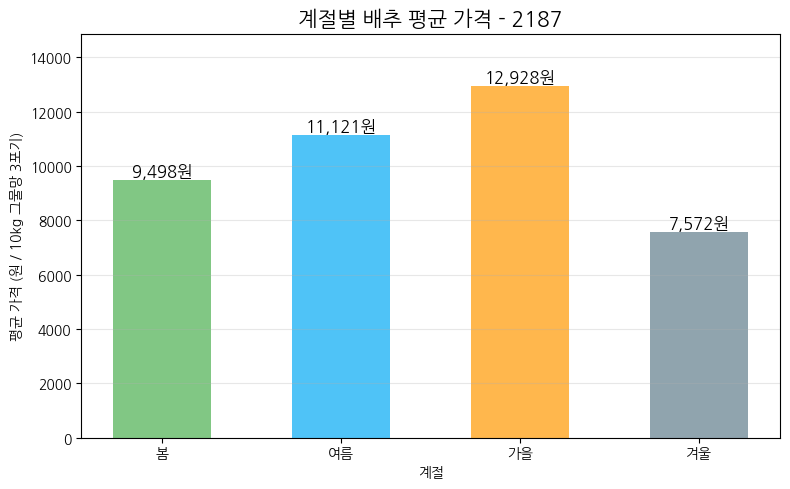

In [8]:
# [STEP 7] 계절별 배추 평균 가격 - 막대 그래프 (문 3-2)
seasonal = df.groupby("season", observed=True)["exmn_dd_prc"].mean()
print("[계절별 평균 가격]")
print(seasonal.round(1))

colors = ["#81C784", "#4FC3F7", "#FFB74D", "#90A4AE"]
plt.figure(figsize=(8, 5))
bars = plt.bar(seasonal.index.astype(str), seasonal.values, color=colors, width=0.55)

for b, v in zip(bars, seasonal.values):          # 각 막대 위에 구체적인 수치 표시
    plt.text(b.get_x() + b.get_width() / 2, v + 150, f"{v:,.0f}원",
             ha="center", fontsize=12, fontweight="bold")

plt.title(f"계절별 배추 평균 가격 - {STUDENT_ID4}", fontsize=15)
plt.xlabel("계절")
plt.ylabel("평균 가격 (원 / 10kg 그물망 3포기)")
plt.ylim(0, seasonal.max() * 1.15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"계절별_배추_평균가격_{STUDENT_ID4}.png", dpi=150)
plt.show()

In [11]:
# [STEP 8] 문 4 해석을 위한 근거 집계표 + 결과 검증
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

print("[1] 연도 × 계절 평균 가격")
display(df.pivot_table(index="year", columns="season", values="exmn_dd_prc",
                       aggfunc="mean", observed=True))

print("[2] 품종별 평균 / 최고 / 최저 / 건수")
display(df.groupby("vrty_label", observed=True)["exmn_dd_prc"].agg(["mean", "max", "min", "count"]))

print("[3] 연도 × 품종 평균 가격")
display(df.pivot_table(index="year", columns="vrty_label", values="exmn_dd_prc",
                       aggfunc="mean", observed=True))

print("[4] 연도별 평균 / 변동성(표준편차) / 최고가")
display(df.groupby("year")["exmn_dd_prc"].agg(["mean", "std", "max"]))

print("[5] 월별 평균 가격 (2015~2024 전체)")
display(df.groupby("month")["exmn_dd_prc"].mean().to_frame("mean"))

print("[6] 가격 상위 10일")
display(df.nlargest(10, "exmn_dd_prc")[["exmn_ymd", "year", "season", "vrty_label", "exmn_dd_prc"]])

pd.reset_option("display.float_format")

# --- 결과 검증 ---
print("검증 1) 총 건수     :", len(df), " / 중복 행 :", df.duplicated(subset=["exmn_ymd", "vrty_cd"]).sum())
print("검증 2) 조사 기간   :", df["exmn_ymd"].min(), "~", df["exmn_ymd"].max())
print("검증 3) 결측 가격   :", df["exmn_dd_prc"].isna().sum())
print("검증 4) 거래 단위   :", df["unit"].unique())

[1] 연도 × 계절 평균 가격


season,봄,여름,가을,겨울
year,,,,
2015,"7,093","6,899","5,036","4,364"
2016,"12,855","9,620","12,846","7,792"
2017,"7,431","10,314","10,141","9,119"
2018,"7,479","11,646","8,969","6,976"
2019,"3,709","7,381","13,348","6,040"
2020,"10,955","13,234","13,863","8,299"
2021,"8,820","7,612","10,087","7,557"
2022,"10,971","15,644","17,591","7,905"
2023,"10,432","14,553","14,644","7,027"


[2] 품종별 평균 / 최고 / 최저 / 건수


,mean,max,min,count
vrty_label,,,,
가을배추,"7,862",16200,3500,447
봄배추,"8,154",15600,3500,531
여름배추(고랭지),"15,441",49800,4000,701
월동배추,"8,843",21000,3000,965


[3] 연도 × 품종 평균 가격


...

[5] 월별 평균 가격 (2015~2024 전체)


,mean
month,
1,"7,076"
2,"8,273"
3,"9,131"
4,"10,208"
5,"9,209"
6,"7,431"
7,"9,894"
8,"15,813"
9,"20,321"


[6] 가격 상위 10일


,exmn_ymd,year,season,vrty_label,exmn_dd_prc
2474,20240913,2024,가을,여름배추(고랭지),49800
2475,20240919,2024,가을,여름배추(고랭지),49800
2477,20240923,2024,가을,여름배추(고랭지),46600
2476,20240920,2024,가을,여름배추(고랭지),46000
1958,20220920,2022,가을,여름배추(고랭지),42600
1951,20220907,2022,가을,여름배추(고랭지),42000
1952,20220908,2022,가을,여름배추(고랭지),40000
2473,20240912,2024,가을,여름배추(고랭지),39800
2472,20240911,2024,가을,여름배추(고랭지),39600
1957,20220919,2022,가을,여름배추(고랭지),39400


검증 1) 총 건수     : 2644  / 중복 행 : 0
검증 2) 조사 기간   : 20150102 ~ 20241231
검증 3) 결측 가격   : 0
검증 4) 거래 단위   : ['kg(그물망 3포기)']
